## 02 - Graph with Multiple Inputs (in State)

In [10]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [11]:
# define the state that will be passed around
# the graph - it should be an instance of TypedDict
class State(TypedDict):
    values: List[int]
    name: str
    result: str

In [12]:
def process_values(state: State) -> dict:
    """this function handles multiple types of inputs"""
    result: str = (
        f"Hi there {state['name']}, the sum of integers is {sum(state['values'])}"
    )
    return {"result": result}

In [13]:
# build out our graph
builder = StateGraph(State)
builder.add_node("process_values", process_values)
# add edges (define structure)
builder.add_edge(START, "process_values")
builder.add_edge("process_values", END)

graph = builder.compile()

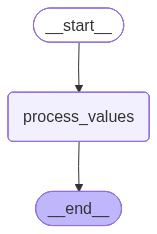

In [14]:
# and let's see how our
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# code block to check value that will be returned
print(sum(list(range(20))))

190


In [16]:
# now invoke the graph
# NOTE: the graph is a Runnable, so it has the invoke() function defined
from rich.console import Console

console = Console()

state = State(
    values=list(range(20)),  # [0, 1, 2...19]
    name="Manish",
    # AM NOT initializing result!
)
response = graph.invoke(state)
# just to get a well-formatted dict displayed in output
console.print(response)
# you should get
# response["result"] == "Hi there Manish, the sum of integers is 190"

{
    'values': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
    'name': 'Manish',
    'result': 'Hi there Manish, the sum of integers is 190'
}

In [17]:
# you can also call the graph like this
# we are partially initializing the State - just the name & values keys
response2 = graph.invoke({"name": "Bob", "values": list(range(25))})
console.print(response2)

{
    'values': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'name': 'Bob',
    'result': 'Hi there Bob, the sum of integers is 300'
}

### Exercise
Create a graph where you pass in a single list of integers along with a name and an operation. If the operation is a `+`, you add the elements and if it is a `*`, you should multiply the elements all within the same node.

**Input:** {"name": "Jack Sparrow", "values": [1,2,3,4], "operation":"*"}

**Output:** "Hi Jack Sparrow, your answer is 24"  # (1 * 2 * 3 * 4 = 24)

**Input:** {"name": "Jack Sparrow", "values": [1,2,3,4], "operation":"+"}

**Output:** "Hi Jack Sparrow, your answer is 10"  # (1 + 2 + 3 + 4 = 10)


In [ ]:
import math


# Step 1: define graph state
class ExState(TypedDict):
    values: List[int]
    name: str
    operation: str
    result: str


# Step 2: define the node(s)
def process_operation(state: ExState) -> dict:
    opr: str = state["operation"].strip()

    if opr not in ["*", "+"]:
        return {
            "result": f"FATAL: unrecognized operation {opr} - should be one of '*' or '+'"
        }

    result = None
    if opr == "*":
        result = math.prod(state["values"])
    elif opr == "+":
        result = sum(state["values"])

    if result is not None:
        ret_val = f"Hi {state["name"]}, your answer is {result}"
    else:
        ret_val = f"Hi {state["name"]}, something went wrong!"

    return {"result": ret_val}


# Step 3: build the graph
builder = StateGraph(ExState)
builder.add_node("math_op", process_operation)
# add edges (define structure)
builder.add_edge(START, "math_op")
builder.add_edge("math_op", END)

graph = builder.compile()

# Step 4: invoke the graph

from rich.console import Console

console = Console()
values, name, operation = [1, 2, 3, 4], "Jack Sparrow", "+"
# try with +
state1 = {"name": name, "values": values, "operation": operation}
response = graph.invoke(state1)
console.print(f"Invoking graph with {state1}")
console.print(response["result"])
# just change the operation
name, operation = "Captain Barbosa", "*"
state2 = {"name": name, "values": values, "operation": operation}
response = graph.invoke(state2)
console.print(f"Invoking graph with {state2}")
console.print(response["result"])

Invoking graph with {'name': 'Jack Sparrow', 'values': [1, 2, 3, 4], 'operation': '+'}

Hi Jack Sparrow, your answer is 10

Invoking graph with {'name': 'Captain Barbosa', 'values': [1, 2, 3, 4], 'operation': '*'}

Hi Captain Barbosa, your answer is 24